In [1]:
import sys
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import csv
sys.path.append('E:\TrackEmission')
import track_emission
from matplotlib import colors

# Specify path and settings

data structure: 

---
basepath<br>
+---oligo_1<br>
|&nbsp; &nbsp;&nbsp;+---tracked_Rapidst_1<br>
|&nbsp; &nbsp;&nbsp;|---tracked_Rapidst_2<br>
|&nbsp; &nbsp;&nbsp;|--- ...<br>
|---oligo_2<br>
|&nbsp; &nbsp;&nbsp;+---tracked_Rapidst_1<br>
|&nbsp; &nbsp;&nbsp;|---tracked_Rapidst_2<br>
|&nbsp; &nbsp;&nbsp;|--- ...<br>
|--- ...<br>

---

tracked_RapidSt: search string for all tracked emitter files from rapidstorm

## calculate ADC counts per photoelectrons $[\frac{ADC}{ph}]$: 

EMCCD: $\frac{gain \cdot \mathrm{quantumefficiency } [\frac{e^-}{ph}]}{\mathrm{sensitivity }[\frac{e^-}{ADC}]}$ <br><br>
sCMOS: $\frac{\mathrm{quantumefficiency }[\frac{e^-}{ph}]}{\mathrm{sensitivity }[\frac{e^-}{ADC}]}$


### Olympus:<br>
- $\frac{200 \cdot 0.98 \frac{e^-}{ph}}{59.2 \frac{e^-}{ADC}} = 3.3108 \frac{ADC}{ph}$ <br>
- (Andor Ixon X5365, readout rate 10 MHz, gain = 200)<br>
- pixelsize = 134

### Nikon:<br>
- $\frac{0.88 \frac{e^-}{ph}}{1.35 \frac{e^-}{ADC}} = 0.6519 \frac{ADC}{ph}$ <br>
- (Gain setting 16-bit, $\lambda$ = 666 nm)
- pixelsize = 122

In [2]:
# path for the tracked file from rapidSTORM:
basepath = r"E:\Fluorocubes\230405_Fluorocubes_AF647_Nikon_EMCCD_crop-mode_100mM-MEA_400mW_quad_line"
oligos = [("1x(0)_AF647_rapidstorm", "1x(0)"),
          ("1x(2)_AF647_rapidstorm", "1x(2)"),
          ("2x_AF647_rapidstorm", "2x"),
          ("4x_AF647_rapidstorm", "4x")
          
         ]
tracked_RapidSt = "*tracked_25nm.txt"

# select exposure time, quantum efficiency and pixelsize:
exposure_time = 5 #[ms]
quant_eff = 8.6
pixelsize = 128 #[nm]
frames = 120000
repetitions = 4
img_dim_x = 256
img_dim_y = 256
final_img_dim_x = 6528
final_img_dim_y = 6528

# basepath to save all plots
base_path = r"E:\Fluorocubes\230405_Fluorocubes_AF647_Nikon_EMCCD_crop-mode_100mM-MEA_400mW_quad_line"

# Extract mean on-time, off-time, intensity and events for all emitter


In [3]:
#emission_statistics_oligos: [(oligo_1, emission_statistics), (oligo_2,emission_statistics), ...]
emission_statistics_oligos = []
tracked_emitter_oligos = []
for oligo, oligo_name in oligos:
    search_path = os.path.join(basepath, oligo, '*'+tracked_RapidSt+'*')
    search_path_list = glob.glob(search_path)
    
    tracked_emitter_all = []
    emission_statistics_all = []
    for file in search_path_list:
        emission_statistics, tracked_emitter = track_emission.extract_rapidstorm(file, exposure_time, quant_eff)
        emission_statistics_all = emission_statistics_all + emission_statistics
        tracked_emitter_all = tracked_emitter_all + tracked_emitter
        file_name = os.path.basename(file)
        print(f'{len(tracked_emitter)} emitter ({file_name})')
    emission_statistics_oligos.append((oligo_name, emission_statistics_all))
    print(f'--> {len(emission_statistics_all)} emitter ({oligo_name})\n')
    tracked_emitter_oligos.append((oligo_name, tracked_emitter_all))


7632 emitter (1x(0)xAF647_5ms_120kfr_Epi_EMCCD_crop_f7,5_400mw_256x256px_quad_line-PFS_0_tracked_25nm.txt)
7203 emitter (1x(0)xAF647_5ms_120kfr_Epi_EMCCD_crop_f7,5_400mw_256x256px_quad_line-PFS_1_tracked_25nm.txt)
7250 emitter (1x(0)xAF647_5ms_120kfr_Epi_EMCCD_crop_f7,5_400mw_256x256px_quad_line-PFS_2_tracked_25nm.txt)
7515 emitter (1x(0)xAF647_5ms_120kfr_Epi_EMCCD_crop_f7,5_400mw_256x256px_quad_line-PFS_3_tracked_25nm.txt)
--> 29600 emitter (1x(0))

4802 emitter (1x(2)xAF647_5ms_120kfr_Epi_EMCCD_crop_f7,5_400mw_256x256px_quad_line-PFS_0_tracked_25nm.txt)
3910 emitter (1x(2)xAF647_5ms_120kfr_Epi_EMCCD_crop_f7,5_400mw_256x256px_quad_line-PFS_1_tracked_25nm.txt)
4137 emitter (1x(2)xAF647_5ms_120kfr_Epi_EMCCD_crop_f7,5_400mw_256x256px_quad_line-PFS_2_tracked_25nm.txt)
4216 emitter (1x(2)xAF647_5ms_120kfr_Epi_EMCCD_crop_f7,5_400mw_256x256px_quad_line-PFS_3_tracked_25nm.txt)
--> 17065 emitter (1x(2))

7639 emitter (2xAF647_5ms_120kfr_Epi_EMCCD_crop_f7,5_400mw_256x256px_quad_line-PFS_0_track

# Filter emitter

## Specify and calculate filters

no filter: "" <br>
higher or equal then e.g.1: "1" <br>

In [31]:
filters = {'filter_on_mean': "5", 
           'filter_on_std': "0", 
           'filter_on_median': "0",
           
           'filter_off_mean': "0.1", 
           'filter_off_std': "0", 
           'filter_off_median': "",
           
           'filter_intensity_mean': "", 
           'filter_intensity_std': "",
           'filter_intensity_median': "",
           
           'filter_events': "3"
          }
filt_emission_statistics_oligos, filt_tracked_emitter_oligos = track_emission.filter_oligos(filters, emission_statistics_oligos, tracked_emitter_oligos)
print(len(filt_emission_statistics_oligos[0][1]))


1x(0) filtered: 
 29600 --> 6009
1x(2) filtered: 
 17065 --> 3800
2x filtered: 
 30186 --> 9883
4x filtered: 
 39272 --> 8862
6009


# Calculate emitter density

In [32]:
area = (img_dim_x * pixelsize * img_dim_y * pixelsize * repetitions)/1000000
print(area)
for oligo in filt_emission_statistics_oligos:
    density = len(oligo[1]) / area
    
    print(density)

4294.967296
1.3990793377161026
0.8847564458847046
2.3010652512311935
2.0633451640605927


# Plot distance of blinking events to the center of cluster
- Kalman filter is initialized with a radius of: $ DT \cdot \sqrt(2) \cdot \sigma_{\frac{x}{y}}$ <br>
    $DT$ = distance threshold <br>
    $\sigma_{\frac{x}{y}}$ = tracking radius [nm]


## Create plot of mean and max distance for all oligos

In [33]:
# x-axis
x_bin = 5.0
x_min_bin = 0
x_max_bin = 100

# y-axis
y_bin = 5.0
y_min_bin = 0
y_max_bin = 100

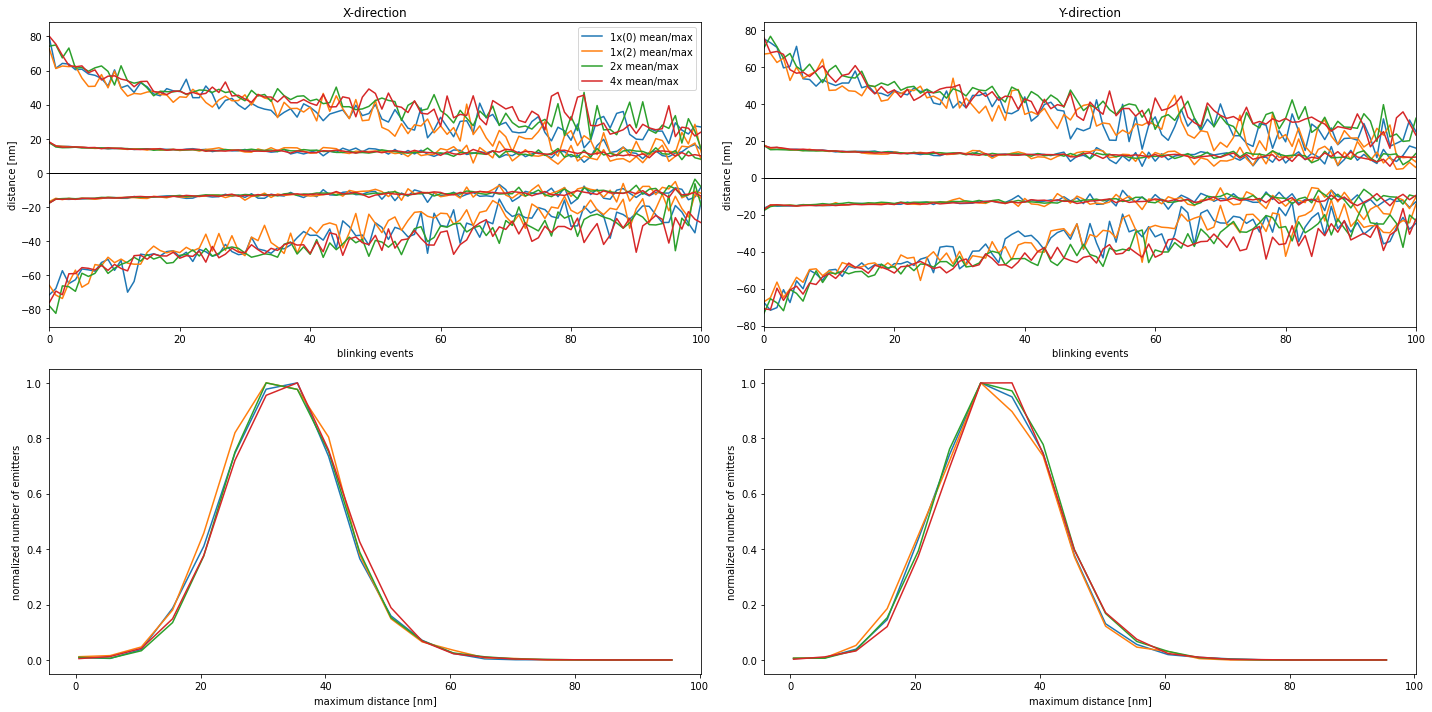

In [34]:
# generate x and y distance statistic
x_position_statistic, y_position_statistic = track_emission.extract_tracking_radius(filt_emission_statistics_oligos, filt_tracked_emitter_oligos)

# plot
fig, axs = plt.subplots(nrows = 2, ncols = 2, tight_layout=True, figsize = (20,10))

ax = plt.gca()
# loop over all oligos:
for oligo_x_position_statistic, oligo_y_position_statistic in zip(x_position_statistic, y_position_statistic):
    
    # x-axis max mean distance
    oligo_name = oligo_x_position_statistic[0]
    color = next(ax._get_lines.prop_cycler)['color']
    #axs[0].plot(x_position_statistic[oligo_number][1], label = f'{oligo_name} min')
    axs[0,0].plot(oligo_x_position_statistic[3], label = f'{oligo_name} mean/max', color = color) # max positive
    axs[0,0].plot(oligo_x_position_statistic[2], color = color) # mean positive
    axs[0,0].plot(oligo_x_position_statistic[5], color = color) #mean negative
    axs[0,0].plot(oligo_x_position_statistic[6], color = color) # max negative
    
    # y-axis max mean distance
    axs[0,1].plot(oligo_y_position_statistic[3], label = f'{oligo_name} mean/max', color = color) # max positive
    axs[0,1].plot(oligo_y_position_statistic[2], color = color) # mean positive
    axs[0,1].plot(oligo_y_position_statistic[6], color = color) # mean negative
    axs[0,1].plot(oligo_y_position_statistic[5], color = color) # max negative
    
    # x-axis histogram
    x_bins = np.arange(x_min_bin, x_max_bin + x_bin, x_bin)
    x_array = np.asarray(oligo_x_position_statistic[7])
    x_hist, x_bin_edges = np.histogram(x_array, x_bins)
    x_hist = (x_hist - np.min(x_hist))/np.ptp(x_hist) # normalize Data between 0 and 1
    x_bin_edges = x_bin_edges[:-1] + 0.5
    axs[1,0].plot(x_bin_edges, x_hist, color = color)
    
    # y-axis histogram
    y_bins = np.arange(y_min_bin, y_max_bin + y_bin, y_bin)
    y_array = np.asarray(oligo_y_position_statistic[7])
    y_hist, y_bin_edges = np.histogram(y_array, y_bins)
    y_hist = (y_hist - np.min(y_hist))/np.ptp(y_hist) # normalize Data between 0 and 1
    y_bin_edges = y_bin_edges[:-1] + 0.5
    axs[1,1].plot(y_bin_edges, y_hist, color = color)

axs[0,0].axhline(linewidth=1, color='black')
axs[0,0].set_xlabel("blinking events")
axs[0,0].set_ylabel("distance [nm]")
axs[0,0].set_title("X-direction")
axs[0,0].set_xlim(0, 100)
#axs[0].set_ylim(-200, 200)
axs[0,0].legend()


axs[0,1].axhline(linewidth=1, color='black')
axs[0,1].set_xlabel("blinking events")
axs[0,1].set_ylabel("distance [nm]")
axs[0,1].set_title("Y-direction")
#axs[,01].legend()
axs[0,1].set_xlim(0, 100)

axs[1,0].set_xlabel("maximum distance [nm]")
axs[1,0].set_ylabel("normalized number of emitters")

axs[1,1].set_xlabel("maximum distance [nm]")
axs[1,1].set_ylabel("normalized number of emitters")

save_path = os.path.join(base_path, f'kalman_filtering_mean_max_distance')
plt.savefig(save_path, dpi=200)
plt.show()

# Plot Histogramms for photostatistic
## Select bins for plots

specify bin width (x_bin), minimum x value (x_min_bin), maximum x value (x_max_bin) and path to save all plots

In [26]:
# on time
on_bin = 1
on_min_bin = 0
on_max_bin = 25

# off time
off_bin = 1.0
off_min_bin = 0
off_max_bin = 100

# intensity
intensity_bin = 5.0
intensity_min_bin = 0
intensity_max_bin = 250

# blinking events
events_bin = 1.0
events_min_bin = 0
events_max_bin = 50

## Plot line Histogramm for on-, off-time, intensity and blinking events

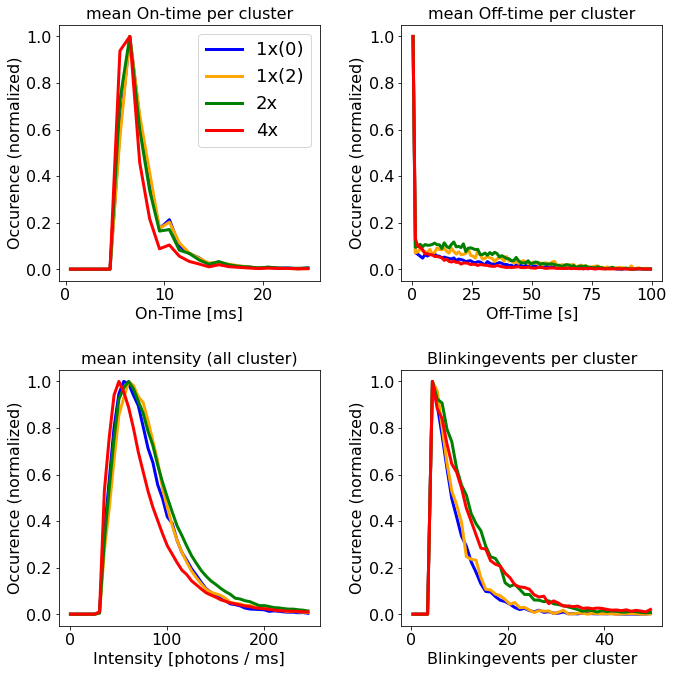

In [27]:
# define bins
on_bins = np.arange(on_min_bin, on_max_bin + on_bin, on_bin)
off_bins = np.arange(off_min_bin, off_max_bin + off_bin, off_bin)
intensity_bins = np.arange(intensity_min_bin, intensity_max_bin + intensity_bin, intensity_bin)
events_bins=np.arange(events_min_bin, events_max_bin + events_bin, events_bin)

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10,10))
color = ['blue', 'orange', 'green', 'red', 'puple']
count = 0

for oligo_name, filt_emission_statistics in filt_emission_statistics_oligos:
    # extract on, off, intensity events from filt_emission_statistics
    on_array, off_array, intensity_array, events_array = track_emission.extract_emitter_parameter(filt_emission_statistics)

    on_hist, on_bin_edges = np.histogram(on_array, on_bins)
    on_hist = (on_hist - np.min(on_hist))/np.ptp(on_hist) # normalize Data between 0 and 1
    on_bin_edges = on_bin_edges[:-1] + 0.5
    axs[0,0].plot(on_bin_edges, on_hist, label = oligo_name, linewidth=3, color = color[count])

    off_hist, off_bin_edges = np.histogram(off_array, off_bins)
    off_hist = (off_hist - np.min(off_hist))/np.ptp(off_hist) # normalize Data between 0 and 1
    off_bin_edges = off_bin_edges[:-1] + 0.5
    axs[0,1].plot(off_bin_edges, off_hist, label = oligo_name, linewidth=3, color = color[count])

    #intensity_hist, intensity_bin_edges = np.histogram(intensity_array, intensity_bins)
    #intensity_hist = (intensity_hist - np.min(intensity_hist))/np.ptp(intensity_hist) # normalize Data between 0 and 1
    #intensity_bin_edges = intensity_bin_edges[:-1]+0.5
    #axs[1,0].plot(intensity_bin_edges, intensity_hist, label = oligo_name, linewidth=3, color = color[count])


    events_hist, events_bin_edges = np.histogram(events_array, events_bins)
    events_hist = (events_hist - np.min(events_hist))/np.ptp(events_hist) # normalize Data between 0 and 1
    events_bin_edges = events_bin_edges[:-1]+0.5
    axs[1,1].plot(events_bin_edges, events_hist, label = oligo_name, linewidth=3, color = color[count])
    count += 1


count = 0
for oligo_name, tracked_emitter in filt_tracked_emitter_oligos:
    
    intensity_list = []
    for event in tracked_emitter:
        intensity_emitter = event[:,6]
        for intensity in intensity_emitter:
            intensity = intensity/quant_eff/exposure_time
            intensity_list.append(intensity)
    #print(intensity_list)
    
    intensity_hist, intensity_bin_edges = np.histogram(intensity_list, intensity_bins)
    intensity_hist = (intensity_hist - np.min(intensity_hist))/np.ptp(intensity_hist) # normalize Data between 0 and 1
    intensity_bin_edges = intensity_bin_edges[:-1] + 0.5
    axs[1,0].plot(intensity_bin_edges, intensity_hist, label = oligo_name, linewidth=3, color = color[count])
    count += 1

#axs[0,0].set_xlabel("on time [ms]")
#axs[0,0].set_ylabel("occurence normalized")
#axs[0,0].set_title("mean on time of emitters")
axs[0,0].set_xlabel("On-Time [ms]", fontsize=16)
axs[0,0].set_ylabel("Occurence (normalized)", fontsize=16)
axs[0,0].set_title("mean On-time per cluster", fontsize=16)
axs[0,0].legend(fontsize=18)
axs[0,0].xaxis.set_tick_params(labelsize=16)
axs[0,0].yaxis.set_tick_params(labelsize=16)
#axs[0,0].legend(title = '2x Linker:', title_fontproperties={'weight':'semibold', 'size':10})
#axs[0,0].text(-0.07, 1.07, 'A', transform=axs[0,0].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')


#axs[0,1].set_xlabel("off time [s]")
#axs[0,1].set_ylabel("occurence normalized")
#axs[0,1].set_title("mean off time of emitters")
axs[0,1].set_xlabel("Off-Time [s]", fontsize=16)
axs[0,1].set_ylabel("Occurence (normalized)", fontsize=16)
axs[0,1].set_title("mean Off-time per cluster", fontsize=16)
axs[0,1].xaxis.set_tick_params(labelsize=16)
axs[0,1].yaxis.set_tick_params(labelsize=16)
#axs[0,1].legend()
#axs[0,1].text(-0.07, 1.07, 'B', transform=axs[0,1].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

#axs[1,0].set_xlabel("intensity [photons]")
#axs[1,0].set_ylabel("occurence normalized")
#axs[1,0].set_title("mean intensity of emitters")
axs[1,0].set_xlabel("Intensity [photons / ms]", fontsize=16)
axs[1,0].set_ylabel("Occurence (normalized)", fontsize=16)
axs[1,0].set_title("mean intensity (all cluster)", fontsize=16)
axs[1,0].xaxis.set_tick_params(labelsize=16)
axs[1,0].yaxis.set_tick_params(labelsize=16)
#axs[1,0].legend()
#axs[1,0].text(-0.07, 1.07, 'C', transform=axs[1,0].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

#axs[1,1].set_xlabel("blinking events")
#axs[1,1].set_ylabel("occurence normalized")
#axs[1,1].set_title("blinking events per emitter")
axs[1,1].set_xlabel("Blinkingevents per cluster", fontsize=16)
axs[1,1].set_ylabel("Occurence (normalized)", fontsize=16)
axs[1,1].set_title("Blinkingevents per cluster", fontsize=16)
axs[1,1].xaxis.set_tick_params(labelsize=16)
axs[1,1].yaxis.set_tick_params(labelsize=16)
fig.tight_layout(pad=3.0, w_pad=3.0, h_pad=3.0)


#axs[1,1].text(-0.07, 1.07, 'D', transform=axs[1,1].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

#axs[1,1].legend()


save_path = os.path.join(base_path, "histogram_combined_lines.png")
plt.savefig(save_path, dpi=200)
plt.show()

## Calculate Intensity for all blinkingevents

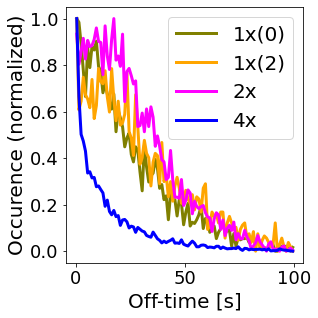

In [32]:
# bins
off_bin = 1.0
off_min_bin = 0
off_max_bin = 100


off_bins = np.arange(off_min_bin, off_max_bin + off_bin, off_bin)

fig, axs = plt.subplots(nrows = 1, ncols = 1, tight_layout=True, figsize = (5,5))
color = ['olive', 'orange', 'magenta', 'blue', 'red']
count = 0
    
for oligo_name, filt_emission_statistics in filt_emission_statistics_oligos:
    on_array, off_array, intensity_array, events_array = track_emission.extract_emitter_parameter(filt_emission_statistics)
    
    off_hist, off_bin_edges = np.histogram(off_array, off_bins)
    off_hist = (off_hist - np.min(off_hist))/np.ptp(off_hist) # normalize Data between 0 and 1
    off_bin_edges = off_bin_edges[:-1] + 0.5
    axs.plot(off_bin_edges, off_hist, label = oligo_name, linewidth=3, color = color[count])
    count += 1
    
axs.set_xlabel("Off-time [s]", fontsize=20)
axs.set_ylabel("Occurence (normalized)", fontsize=20)
axs.xaxis.set_tick_params(labelsize=18)
axs.yaxis.set_tick_params(labelsize=18)
#axs.set_title("mean intensity")
axs.legend(fontsize=20)

save_path = os.path.join(base_path, "histogram_intensity.png")
plt.savefig(save_path, dpi=200)
plt.show()

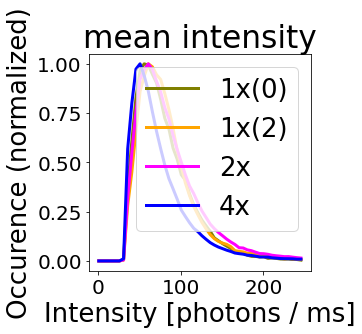

In [33]:
# bins
intensity_a_bin = 5
intensity_a_min_bin = 0
intensity_a_max_bin = 250


intensity_bins = np.arange(intensity_a_min_bin, intensity_a_max_bin + intensity_a_bin, intensity_a_bin)

fig, axs = plt.subplots(nrows = 1, ncols = 1, tight_layout=True, figsize = (5,5))

color = ['olive', 'orange', 'magenta', 'blue', 'red']
count = 0
for oligo_name, tracked_emitter in filt_tracked_emitter_oligos:
    
    intensity_list = []
    for event in tracked_emitter:
        intensity_emitter = event[:,6]
        for intensity in intensity_emitter:
            intensity = intensity/quant_eff/exposure_time
            intensity_list.append(intensity)
    #print(intensity_list)
    
    intensity_hist, intensity_bin_edges = np.histogram(intensity_list, intensity_bins)
    intensity_hist = (intensity_hist - np.min(intensity_hist))/np.ptp(intensity_hist) # normalize Data between 0 and 1
    intensity_bin_edges = intensity_bin_edges[:-1] + 0.5
    axs.plot(intensity_bin_edges, intensity_hist, label = oligo_name, linewidth=3, color = color[count])
    count += 1
    
axs.set_xlabel("Intensity [photons / ms]")
axs.set_ylabel("Occurence (normalized)")
axs.set_title("mean intensity")
axs.legend()
axs.xaxis.set_tick_params(labelsize=20)
axs.yaxis.set_tick_params(labelsize=20)

save_path = os.path.join(base_path, "histogram_intensity.png")
plt.savefig(save_path, dpi=200)
plt.show()

## Plot line Histogramm for events and intensity against time

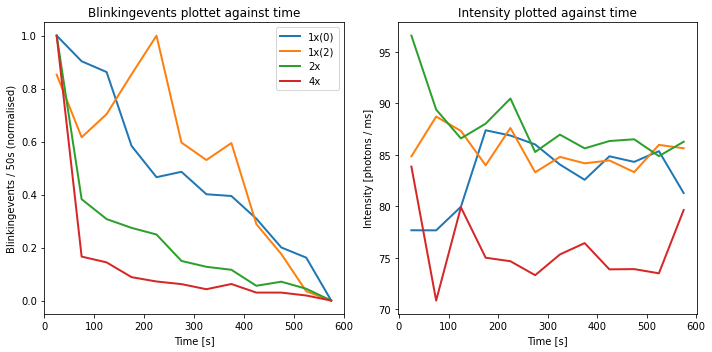

In [36]:
## plot
fig, axs = plt.subplots(nrows = 1, ncols = 2, tight_layout=True, figsize = (10,5))
oligo_number = 0
for oligo_name, filt_emission_statistics in filt_emission_statistics_oligos:

    # generate emitter profiles
    emitter_profiles = track_emission.extract_emitters(oligo_number, filt_emission_statistics_oligos, tracked_emitter_oligos, exposure_time, quant_eff)
    
    # extract emitter intensities and events:
    bin_width = 50 # bin_width must be evenly dicisible bay frame number 
    temp_bin, events, intensity_mean = track_emission.extract_intensity_events(emitter_profiles, bin_width, frames, exposure_time)

    axs[0].plot(temp_bin, events, label = oligo_name, linewidth=2)

    axs[1].plot(temp_bin, intensity_mean , label = oligo_name, linewidth=2)
    
    oligo_number += 1


#axs[0].set_xlabel("time [s]")
#axs[0].set_ylabel(f'events / {bin_width}s normalized')
#axs[0].set_title("events plotted against time")

axs[0].set_xlabel("Time [s]")
axs[0].set_ylabel(f'Blinkingevents / {bin_width}s (normalised)')
axs[0].set_title("Blinkingevents plottet against time")
axs[0].set_xlim(0, 600)
axs[0].legend()
#axs[0].legend(title = '2x Linker:', title_fontproperties={'weight':'semibold', 'size':10})
#axs[0].text(-0.07, 1.07, 'E', transform=axs[0].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')



#axs[1].set_xlabel("time [s]")
#axs[1].set_ylabel("intensity [ADC]")
#axs[1].set_title("intensity plotted against time")
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("Intensity [photons / ms]")
axs[1].set_title("Intensity plotted against time")
#axs[1].legend()
#axs[1].text(-0.07, 1.07, 'F', transform=axs[1].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

save_path = os.path.join(base_path, "events_intensity_over_time.png")
plt.savefig(save_path, dpi=200)
plt.show()

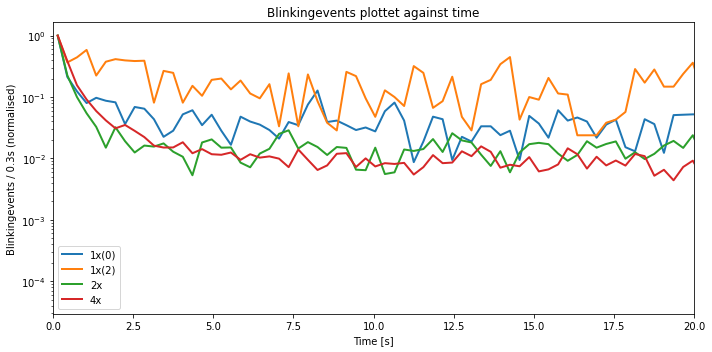

In [8]:
## plot
fig, axs = plt.subplots(nrows = 1, ncols = 1, tight_layout=True, figsize = (10,5))
oligo_number = 0
for oligo_name, filt_emission_statistics in filt_emission_statistics_oligos:

    # generate emitter profiles
    emitter_profiles = track_emission.extract_emitters(oligo_number, filt_emission_statistics_oligos, tracked_emitter_oligos, exposure_time, quant_eff)
    
    # extract emitter intensities and events:
    bin_width = 0.3 # bin_width must be evenly dicisible bay frame number 
    temp_bin, events, intensity_mean = track_emission.extract_intensity_events(emitter_profiles, bin_width, frames, exposure_time)

    axs.plot(temp_bin, events, label = oligo_name, linewidth=2)

    
    oligo_number += 1


#axs[0].set_xlabel("time [s]")
#axs[0].set_ylabel(f'events / {bin_width}s normalized')
#axs[0].set_title("events plotted against time")

axs.set_xlabel("Time [s]")
axs.set_ylabel(f'Blinkingevents / {bin_width}s (normalised)')
axs.set_title("Blinkingevents plottet against time")
axs.set_xlim(0, 20)
axs.legend()
plt.yscale("log")
#axs[0].legend(title = '2x Linker:', title_fontproperties={'weight':'semibold', 'size':10})
#axs.text(-0.07, 1.07, 'E', transform=axs[0].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')




save_path = os.path.join(base_path, "events_intensity_over_time.png")
plt.savefig(save_path, dpi=200)
plt.show()

# Create table for photostatistic

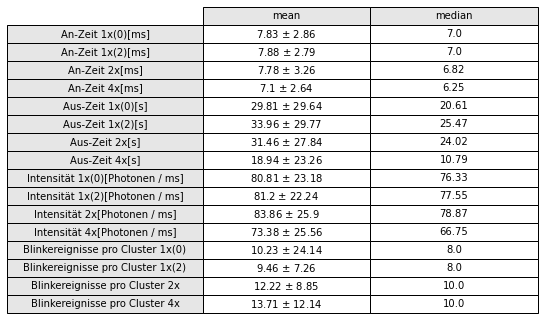

In [9]:
statistic, rows = track_emission.calc_rows_statistic(filt_emission_statistics_oligos)

fig, ax = plt.subplots()

# hide axes
fig.patch.set_visible(False)

ax.axis('off')
ax.axis('tight')

columns = ["mean", "median"]

table = ax.table(cellText=statistic, 
         colLabels=columns, 
         rowLabels = rows, 
         loc='center', 
         cellLoc = 'center', 
         rowLoc = 'center', 
         rowColours = ['0.9'] * len(rows),
         colColours = ['0.9'] * len(columns),
         )

table.scale(1, 1.5)
  
#plt.show()

save_path = os.path.join(base_path, "statistic_table.png")
plt.savefig(save_path, dpi=800, bbox_inches='tight')
plt.show()

# generate csv
header = ['' , 'Mittelwert', 'Standardabweichung', 'Median']
dataset = []
for row, data_line in zip(rows, statistic):
    mean = data_line[0].split()
    dataset.append([row, mean[0], mean[2], data_line[1]])

# save csv
csv_path = os.path.join(base_path, "statistic_table.csv")
with open(csv_path, 'w', encoding='UTF8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(dataset)

# Display 80% image

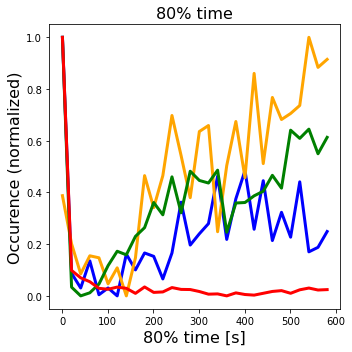

In [28]:
time_bin = 20
time_min_bin = 0
time_max_bin = 600

time_bins = np.arange(time_min_bin, time_max_bin + time_bin, time_bin)
fig, axs = plt.subplots(nrows = 1, ncols = 1, tight_layout=True, figsize = (5,5))
color = ['blue', 'orange', 'green', 'red', 'puple']

# for csv
header = ['' , 'Mittelwert', 'Standardabweichung', 'Median']
dataset = []

count = 0
for sample, emitter in filt_tracked_emitter_oligos:
    time = []
    for cluster in emitter:
        on_frames = cluster[:,5]
        timepoint = round(0.8*len(on_frames))
        time_frames = on_frames[timepoint]
        time_s = (time_frames*exposure_time)/1000
        time.append(time_s)
    time_array = np.asarray(time)
    
    time_hist, time_bin_edges = np.histogram(time_array, time_bins)
    time_hist = (time_hist - np.min(time_hist))/np.ptp(time_hist) # normalize Data between 0 and 1
    time_bin_edges = time_bin_edges[:-1] + 0.5
    axs.plot(time_bin_edges, time_hist, label = f'{sample}', linewidth=3, color = color[count])
    
    mean_number = np.mean(time_array).round(2)
    std_number = np.std(time_array).round(2)
    median_number = np.median(time_array).round(2)
    dataset.append([sample, mean_number, std_number, median_number])
    
    count += 1
    


# save csv
csv_path = os.path.join(base_path, "80time_table.csv")
with open(csv_path, 'w', encoding='UTF8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(dataset)
    
#axs.legend(fontsize=18)
axs.set_xlabel("80% time [s]", fontsize=16)
#axs.legend()
axs.set_ylabel(f'Occurence (normalized)', fontsize=16)
axs.set_title("80% time", fontsize=16)
#axs.xaxis.set_tick_params(labelsize=16)
#axs.yaxis.set_tick_params(labelsize=16)
#fig.tight_layout(pad=3.0, w_pad=3.0, h_pad=3.0)
save_path = os.path.join(base_path, f'80% imaging')
plt.savefig(save_path, dpi=200, bbox_inches='tight')

In [1]:
for sample, emitter in filt_tracked_emitter_oligos:
    image_array = np.zeros((round((final_img_dim_x+1)/4), round((final_img_dim_y+1)/4))) # divide by 20/5 = 4
    print(sample)
    for cluster in emitter:
        # position
        x_pos = cluster[:,1]
        y_pos = cluster[:,3]
        x_array = np.asarray(x_pos)
        y_array = np.asarray(y_pos)
        #x_mean = int(np.mean(x_array))
        #y_mean = int(np.mean(y_array))
        x_mean = int(round(np.mean(x_array))/20)
        y_mean = int(round(np.mean(y_array))/20)
        
        # 80% Time
        on_frames = cluster[:,5]
        timepoint = round(0.8*len(on_frames))
        time_frames = on_frames[timepoint]
        time_s = (time_frames*exposure_time)/1000
        
        image_array[x_mean-5:x_mean+5, y_mean-5:y_mean+5] = time_s
    image_array_rot = np.rot90(image_array, k=1, axes=(1,0))
        
    fig, ax = plt.subplots(figsize=(20, 20))
    plt.rcParams.update({'font.size': 26})
    plt.imshow(image_array_rot, interpolation='nearest', cmap='jet', norm=colors.LogNorm(vmin=0.001, vmax=600.0))
    ax.invert_xaxis()
    ax.set_xlabel("X-Position (20 nm binning)", fontsize=26)
    ax.set_ylabel("Y-Position (20 nm binning)", fontsize=26)
    cbar = plt.colorbar()
    cbar.ax.tick_params(labelsize=26)
    cbar.set_label('80% Time [s]', fontsize=26)

    save_path = os.path.join(base_path, f'{sample} image')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    
    
    

NameError: name 'filt_tracked_emitter_oligos' is not defined

# Plot emission profiles
## Plot a single emission profile
specify path to save the plot and the number of a emitter

In [82]:
# number of emitter
num_emitter =1
# oligo
oligo_number = 1

'''# number of emitter
num_emitter =56
# oligo
oligo_number = 4'''

'# number of emitter\nnum_emitter =56\n# oligo\noligo_number = 4'

Emitter 1 of 219


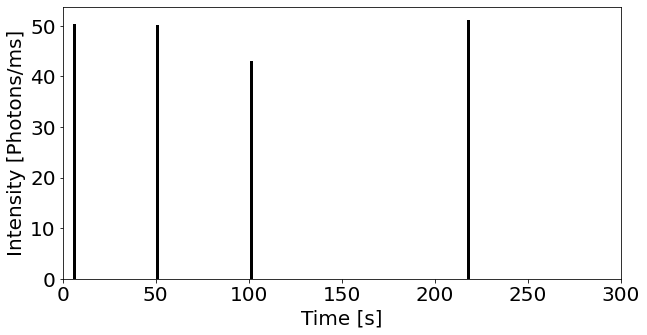

In [83]:
# path for saving the plot
file_name = f'emitter_{num_emitter}_{filt_emission_statistics_oligos[oligo_number][0]}.png'
save_path = os.path.join(base_path, file_name)

emitter_profiles = track_emission.extract_emitters(oligo_number, filt_emission_statistics_oligos, tracked_emitter_oligos, exposure_time, quant_eff)
    
# plot emission profile
frame = emitter_profiles[num_emitter][1]
intensity = emitter_profiles[num_emitter][2]

fig, axs = plt.subplots(figsize=(10, 5))
axs.bar(x=frame, height=intensity, width=1.5, color = 'k')
#axs.set_title(f'Emission profile of emitter {num_emitter} ({filt_emission_statistics_oligos[oligo_number][0]})')
axs.set_xlabel(r'Time [s]', fontsize=20)
axs.set_ylabel("Intensity [Photons/ms]", fontsize=20)
axs.xaxis.set_tick_params(labelsize=20)
axs.yaxis.set_tick_params(labelsize=20)
plt.xlim([0,300])

plt.savefig(save_path)
print(f'Emitter {num_emitter} of {len(filt_emission_statistics_oligos[oligo_number][1])-1}')
plt.show()

## Plot interval of emission profiles:
From position *start* to position *end* or x emitter around median blinking events.

In [16]:
oligo_number = 3

# if around median, median = True
median = True
number_around_median = 12

# else define start and end
start = 0
end = 11


In [17]:
print(f'Emitter {len(filt_emission_statistics_oligos[oligo_number][1])-1}')

Emitter 8861


## Calculate 12 emitter profiles in one plot

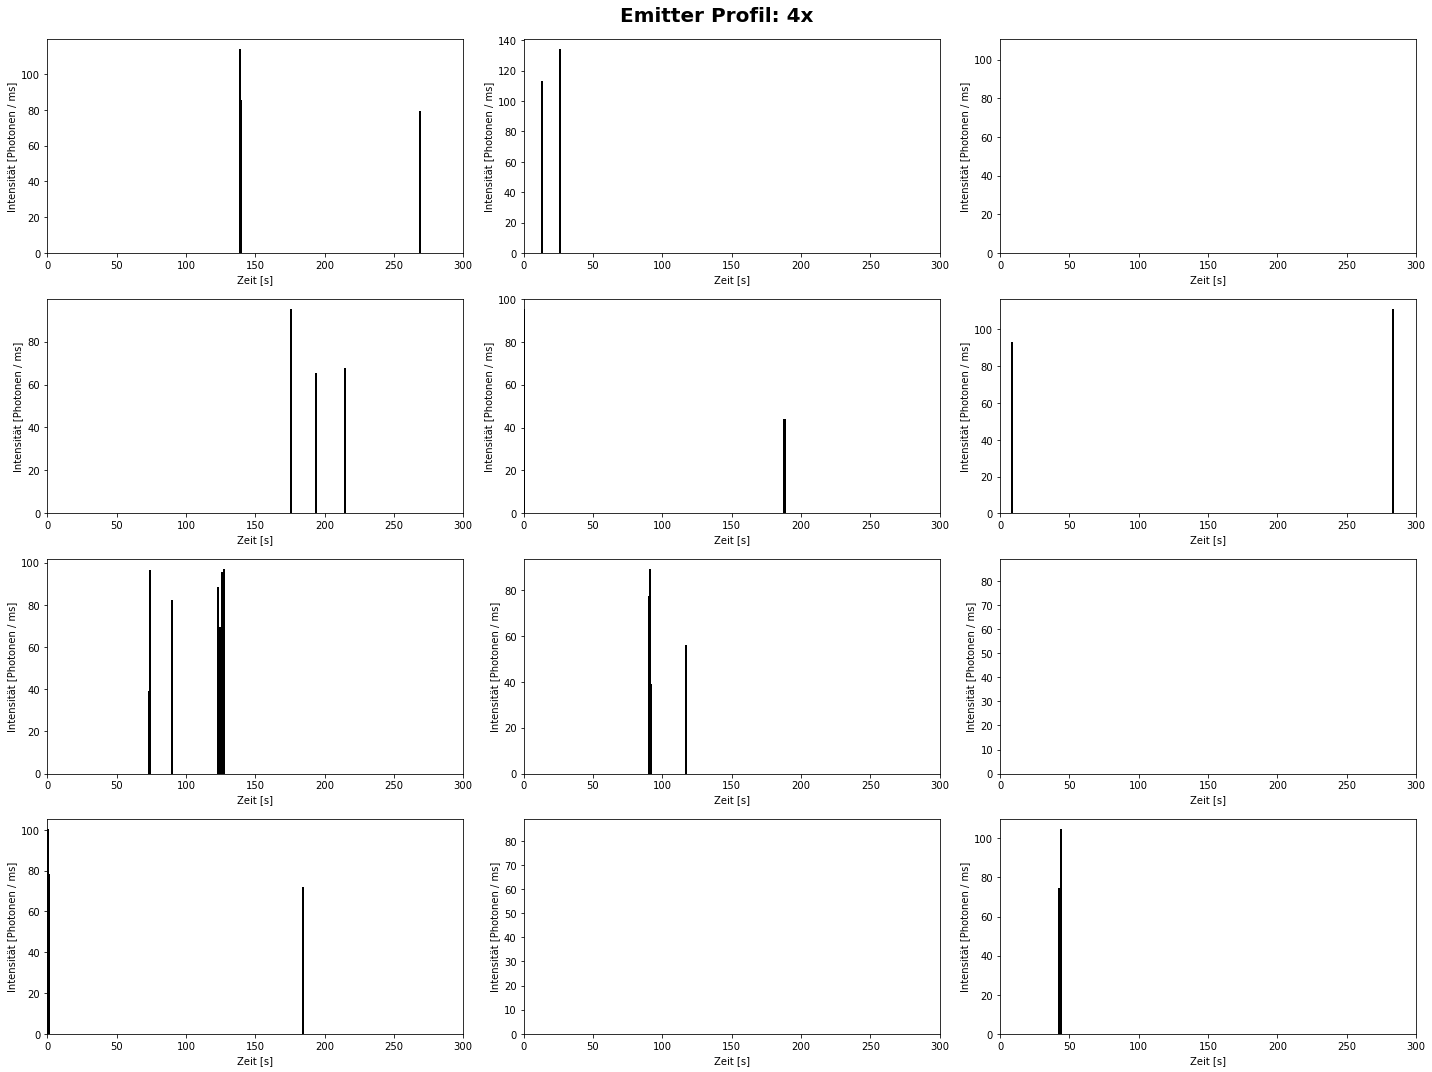

In [18]:
emitter_profiles = track_emission.extract_emitters(oligo_number, filt_emission_statistics_oligos, tracked_emitter_oligos, exposure_time, quant_eff)
# calculate start and end value:
if median:
    start = math.ceil((len(emitter_profiles) / 2) - (12/2))
    end = math.ceil((len(emitter_profiles) / 2) + (12/2))
count = start

fig, axs = plt.subplots(nrows = 4, ncols = 3, tight_layout=True, figsize = (20,15))
row = [0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3]
col = [0, 1, 2]*4
r_pos = 0
c_pos = 0
while count < end and count < len(emitter_profiles):
    frame = emitter_profiles[count][1]
    intensity = emitter_profiles[count][2]
    
    #fig, axs = plt.subplots(figsize=(15, 5))
    axs[row[r_pos]][col[c_pos]].bar(x=frame, height=intensity, width=1.5, color = 'k')
    a = (emitter_profiles[count][0])
    #axs[row[r_pos]][col[c_pos]].set_title(f'Emission profile of emitter {int(emitter_profiles[count][0][0])} ({filt_emission_statistics_oligos[oligo_number][0]})')
    axs[row[r_pos]][col[c_pos]].set_xlabel("Zeit [s]")
    axs[row[r_pos]][col[c_pos]].set_ylabel("Intensität [Photonen / ms]")
    axs[row[r_pos]][col[c_pos]].set_xlim([0,300])
    r_pos += 1
    c_pos += 1
    count += 1
fig.suptitle(F'Emitter Profil: {filt_emission_statistics_oligos[oligo_number][0]}', fontsize=20, fontweight='bold', y=0.99)

save_path = os.path.join(base_path, f'emission_profiles_{filt_emission_statistics_oligos[oligo_number][0]}')
plt.savefig(save_path, dpi=200)
plt.show()

In [58]:
emitter_profiles = track_emission.extract_emitters(oligo_number, filt_emission_statistics_oligos, tracked_emitter_oligos, exposure_time, quant_eff)
print(emitter_profiles[0])
print("k")

print(emitter_profiles[3463])

[[3519.0], [0.75, 0.78, 0.805, 0.81, 60.685], array([41.750233, 39.736744, 42.712322, 41.997906, 38.33395 ],
      dtype=float32), 1.6217512182883376]
k
[[6604.0], [0.0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1, 0.105, 0.11, 0.115, 0.12, 0.125, 0.13, 0.145, 0.15, 0.16, 0.165, 0.17, 0.175, 0.18, 0.185, 0.19, 0.195, 0.2, 0.22, 0.355, 0.41, 0.535, 1.19, 5.585, 10.555, 11.095], array([1740.6559  , 1789.237   , 1718.8138  , 1702.1882  , 1584.1768  ,
       1833.823   , 2042.2162  , 1765.6907  , 2108.0396  , 1918.6953  ,
       1899.1907  , 1669.6511  , 1823.1859  , 1621.3324  , 1525.6069  ,
       1552.6487  , 1504.8418  , 1685.2698  , 1517.879   , 1500.2046  ,
       1428.4954  , 1574.7441  , 1542.1975  , 1172.972   , 1320.779   ,
       1132.2604  , 1168.8813  , 1016.6046  , 1011.7093  ,  724.29767 ,
        674.6581  ,  802.80927 ,  644.68835 ,  766.18604 ,  736.7651  ,
        777.69525 ,  594.64185 ,

## Calculate emitter profiles and save them

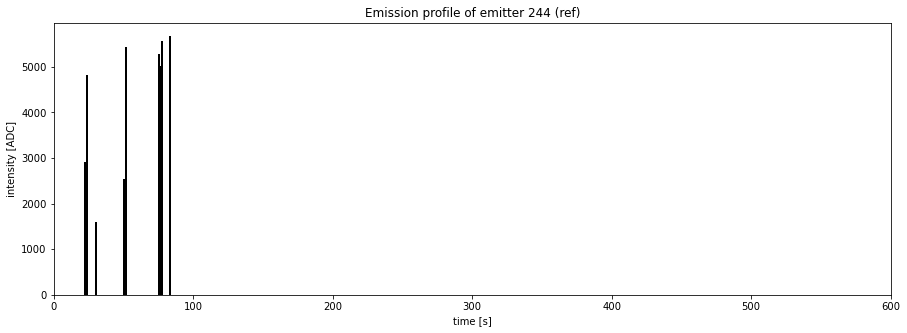

Emission profile of emitter 244 (ref) saved


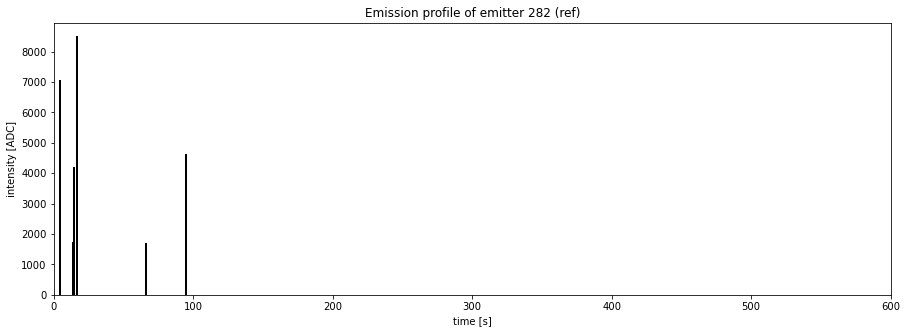

Emission profile of emitter 282 (ref) saved


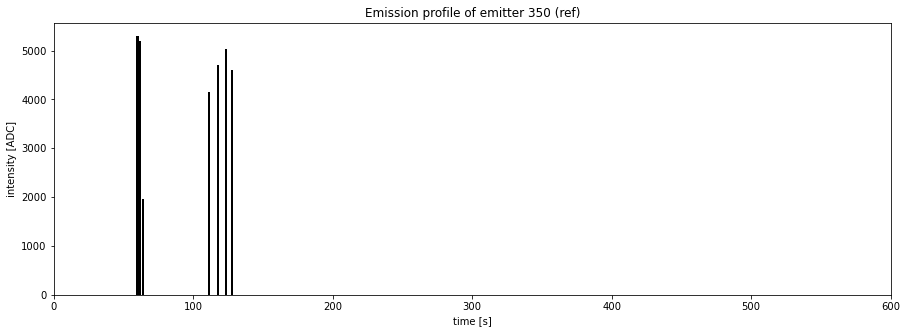

Emission profile of emitter 350 (ref) saved


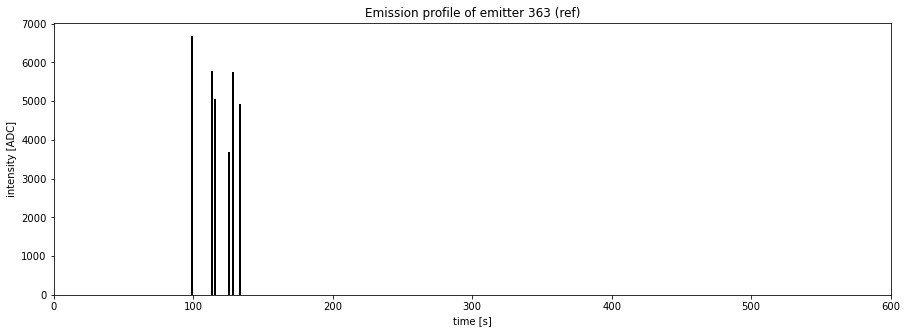

Emission profile of emitter 363 (ref) saved


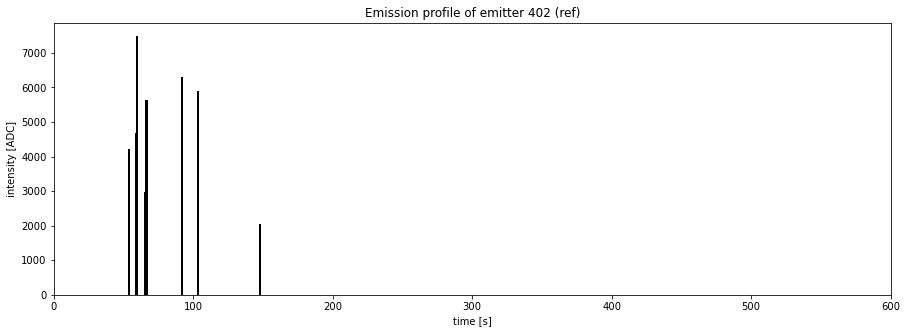

Emission profile of emitter 402 (ref) saved


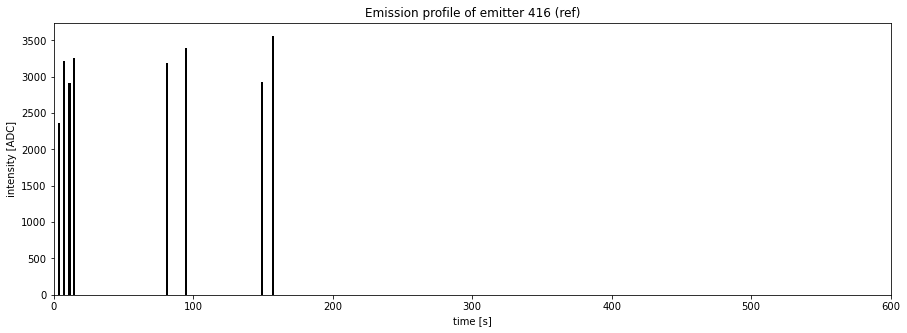

Emission profile of emitter 416 (ref) saved


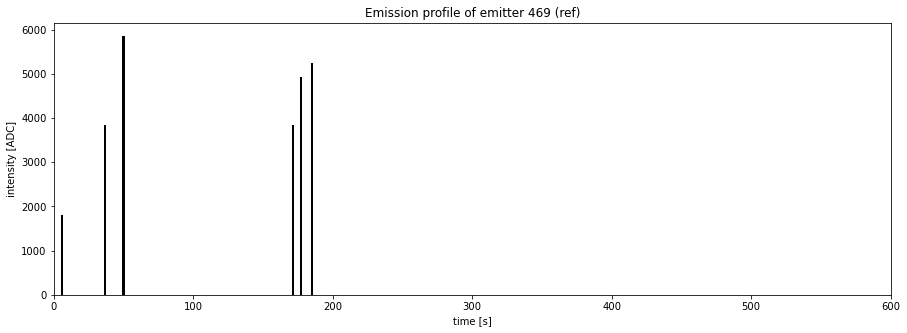

Emission profile of emitter 469 (ref) saved


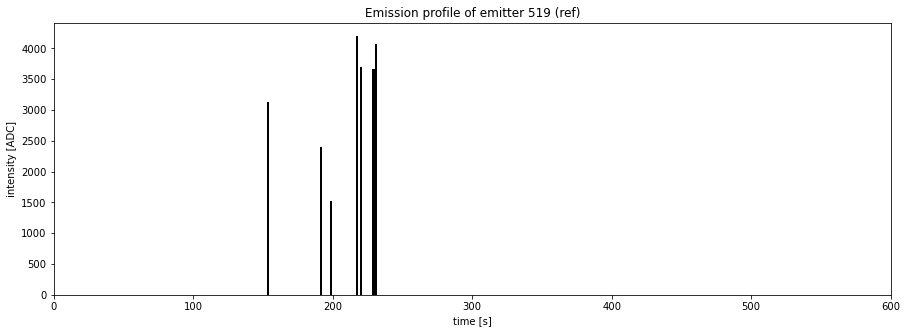

Emission profile of emitter 519 (ref) saved


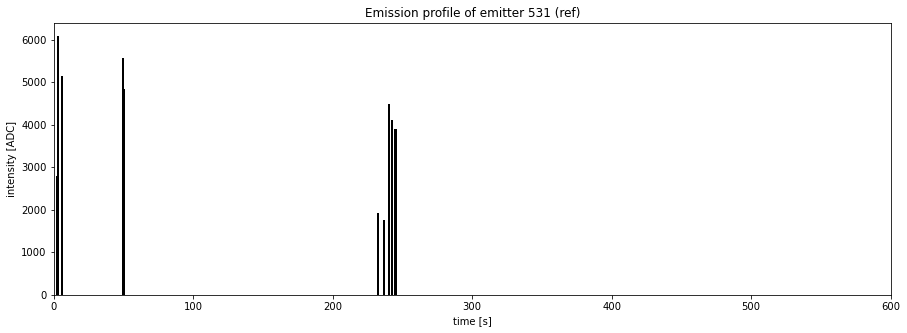

Emission profile of emitter 531 (ref) saved


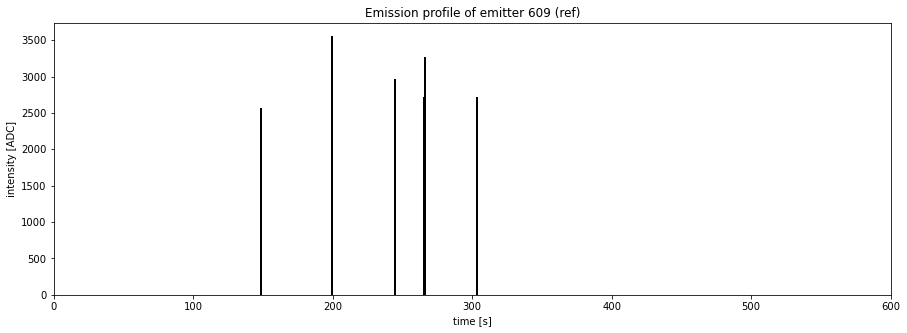

Emission profile of emitter 609 (ref) saved


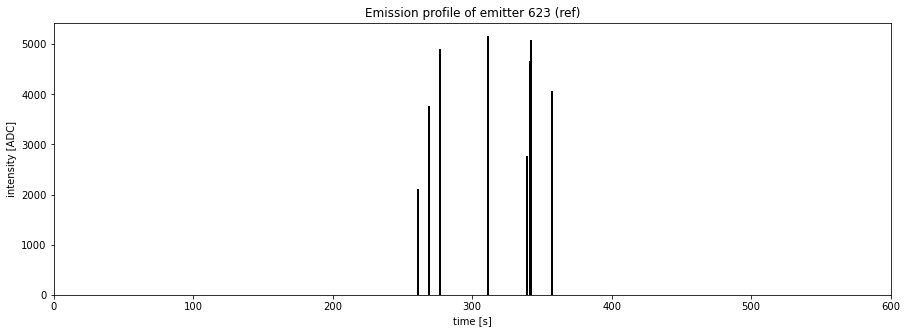

Emission profile of emitter 623 (ref) saved


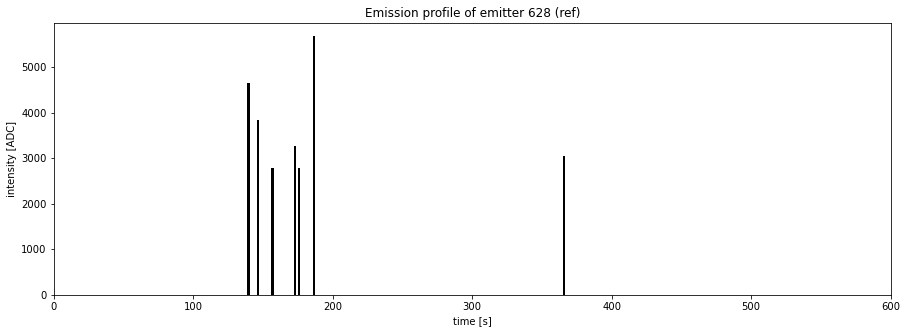

Emission profile of emitter 628 (ref) saved


In [37]:
emitter_profiles = track_emission.extract_emitters(oligo_number, filt_emission_statistics_oligos, tracked_emitter_oligos, exposure_time)

# check if median and calculate start and end value:
if median:
    start = math.ceil((len(emitter_profiles) / 2) - (number_around_median/2))
    end = math.ceil((len(emitter_profiles) / 2) + (number_around_median/2))
count = start

while count < end and count < len(emitter_profiles):
    frame = emitter_profiles[count][1]
    intensity = emitter_profiles[count][2]
    
    fig, axs = plt.subplots(figsize=(15, 5))
    axs.bar(x=frame, height=intensity, width=1.5, color = 'k')
    a = (emitter_profiles[count][0])
    axs.set_title(f'Emission profile of emitter {int(emitter_profiles[count][0][0])} ({filt_emission_statistics_oligos[oligo_number][0]})')
    axs.set_xlabel("time [s]")
    axs.set_ylabel("intensity [ADC]")
    plt.xlim([0,600])
    path = os.path.join(base_path, 
                        f'emission_profiles_{filt_emission_statistics_oligos[oligo_number][0]}')
    if not os.path.exists(path):
        os.mkdir(path)
    save = os.path.join(base_path, 
                        f'emission_profiles_{filt_emission_statistics_oligos[oligo_number][0]}', 
                        f'emitter_{count}.jpeg')
    plt.savefig(save)
    plt.show()
    plt.close()
    print(f'Emission profile of emitter {int(emitter_profiles[count][0][0])} ({filt_emission_statistics_oligos[oligo_number][0]}) saved')
    count += 1
    


# Old stuff

In [7]:
# on time
on_bin = 5.0
on_min_bin = 0
on_max_bin = 80

# off time
off_bin = 1.0
off_min_bin = 0
off_max_bin = 25

# intensity
intensity_bin = 20.0
intensity_min_bin = 50
intensity_max_bin = 500

# blinking events
events_bin = 1.0
events_min_bin = 0
events_max_bin = 50

# basepath to save all plots
base_path = r"E:\Rick_data\0_test_track_emission_script\210421_cy5-oligos_ref_5nm_15nm_5ms_10min"

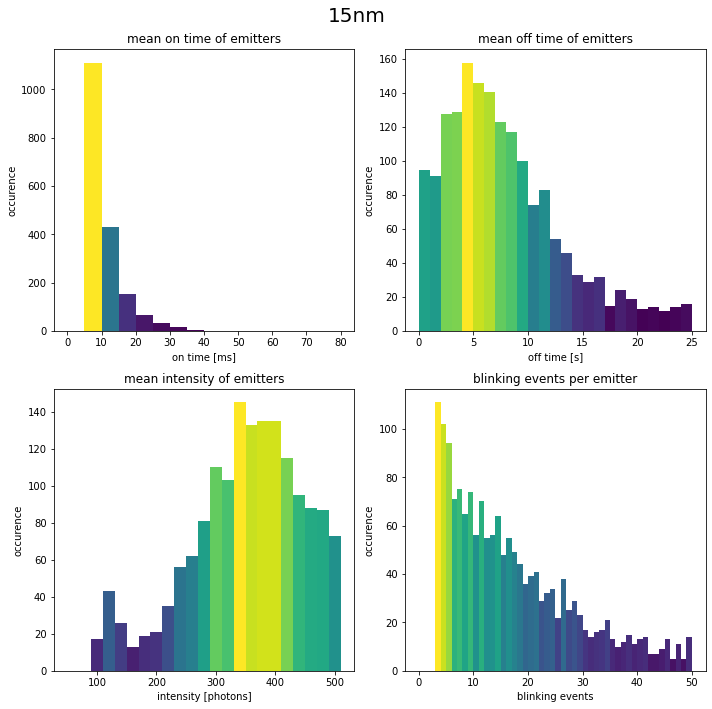

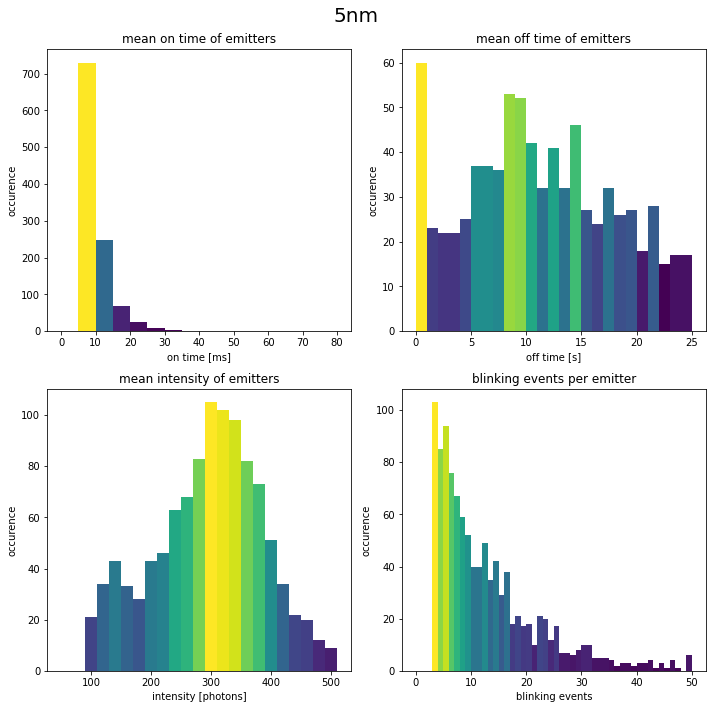

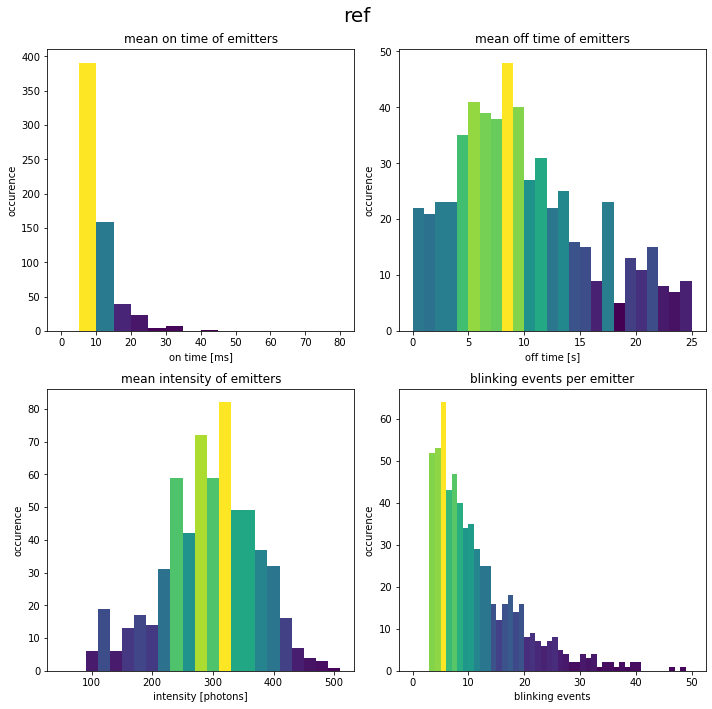

In [38]:
# define bins
on_bins = np.arange(on_min_bin, on_max_bin + on_bin, on_bin)
off_bins = np.arange(off_min_bin, off_max_bin + off_bin, off_bin)
intensity_bins = np.arange(intensity_min_bin, intensity_max_bin + intensity_bin, intensity_bin)
events_bins=np.arange(events_min_bin, events_max_bin + events_bin, events_bin)

for oligo_name, filt_emission_statistics in filt_emission_statistics_oligos:

    on_array, off_array, intensity_array, events_array = track_emission.extract_emitter_parameter(filt_emission_statistics)


    fig, axs = plt.subplots(nrows = 2, ncols = 2, tight_layout=True, figsize = (10,10))


    N, bins, patches = axs[0,0].hist(on_array, bins = on_bins, histtype = "bar")
    fracs = N / N.max()
    norm = colors.Normalize(fracs.min(), fracs.max())
    for thisfrac, thispatch in zip(fracs, patches):
        color = plt.cm.viridis(norm(thisfrac))
        thispatch.set_facecolor(color)
    axs[0,0].set_xlabel("on time [ms]")
    axs[0,0].set_ylabel("occurence")
    axs[0,0].set_title("mean on time of emitters")


    N, bins, patches = axs[0,1].hist(off_array, bins = off_bins , histtype = "bar")
    fracs = N / N.max()
    norm = colors.Normalize(fracs.min(), fracs.max())
    for thisfrac, thispatch in zip(fracs, patches):
        color = plt.cm.viridis(norm(thisfrac))
        thispatch.set_facecolor(color)
    axs[0,1].set_xlabel("off time [s]")
    axs[0,1].set_ylabel("occurence")
    axs[0,1].set_title("mean off time of emitters")

    N, bins, patches = axs[1,0].hist(intensity_array, bins = intensity_bins, histtype = "bar")
    fracs = N / N.max()
    norm = colors.Normalize(fracs.min(), fracs.max())
    for thisfrac, thispatch in zip(fracs, patches):
        color = plt.cm.viridis(norm(thisfrac))
        thispatch.set_facecolor(color)
    axs[1,0].set_xlabel("intensity [photons]")
    axs[1,0].set_ylabel("occurence")
    axs[1,0].set_title("mean intensity of emitters")

    N, bins, patches = axs[1,1].hist(events_array, bins = events_bins, histtype = "bar")
    fracs = N / N.max()
    norm = colors.Normalize(fracs.min(), fracs.max())
    for thisfrac, thispatch in zip(fracs, patches):
        color = plt.cm.viridis(norm(thisfrac))
        thispatch.set_facecolor(color)
    axs[1,1].set_xlabel("blinking events")
    axs[1,1].set_ylabel("occurence")
    axs[1,1].set_title("blinking events per emitter")
    
    plt.suptitle(oligo_name,fontsize=20)
    
    save_path = os.path.join(base_path, "histogram_" + oligo_name + ".png")
    plt.savefig(save_path, dpi=200)
    plt.show()

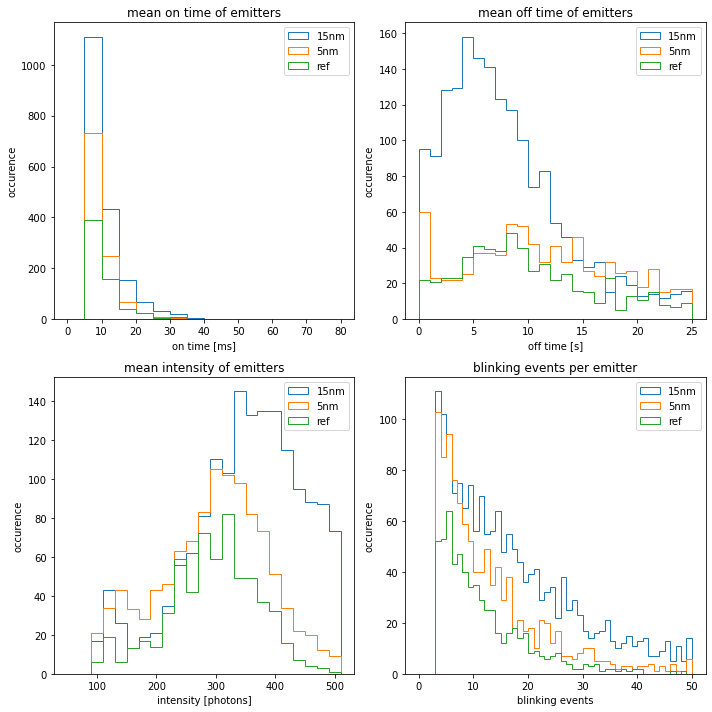

In [39]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, tight_layout=True, figsize = (10,10))

for oligo_name, filt_emission_statistics in filt_emission_statistics_oligos:

    on_array, off_array, intensity_array, events_array = track_emission.extract_emitter_parameter(filt_emission_statistics)
    
    axs[0,0].hist(on_array, bins = on_bins, histtype = "step", label = oligo_name)
    
    
    axs[0,1].hist(off_array, bins = off_bins , histtype = "step", label = oligo_name)
    
    
    axs[1,0].hist(intensity_array, bins = intensity_bins, histtype = "step", label = oligo_name)
    
    
    axs[1,1].hist(events_array, bins = events_bins, histtype = "step", label = oligo_name)

    

axs[0,0].set_xlabel("on time [ms]")
axs[0,0].set_ylabel("occurence")
axs[0,0].set_title("mean on time of emitters")
axs[0,0].legend()


axs[0,1].set_xlabel("off time [s]")
axs[0,1].set_ylabel("occurence")
axs[0,1].set_title("mean off time of emitters")
axs[0,1].legend()

axs[1,0].set_xlabel("intensity [photons]")
axs[1,0].set_ylabel("occurence")
axs[1,0].set_title("mean intensity of emitters")
axs[1,0].legend()

axs[1,1].set_xlabel("blinking events")
axs[1,1].set_ylabel("occurence")
axs[1,1].set_title("blinking events per emitter")
axs[1,1].set_linewidth=10

axs[1,1].legend()


save_path = os.path.join(base_path, "histogram_combined_hist.png")
plt.savefig(save_path, dpi=200)
plt.show()

# Experimental / To Do

In [31]:
# simulate tracking radius

sigma_xy = 10.0
uncertainty_trace = sigma_xy # initialise
for i in range(20):
    distancethreshold = uncertainty_trace*math.sqrt(2) + math.sqrt(2)*sigma_xy
    uncertainty_trace = distancethreshold/4
    print(distancethreshold)

28.284271247461902
24.14213562373095
22.67766952966369
22.15990257669732
21.976844314938912
21.912123445818118
21.889241163098315
21.881151054458215
21.87829076911824
21.87727950553823
21.876921969870732
21.87679556192323
21.876750869964795
21.876735068971357
21.876729482476552
21.87672750735237
21.87672680904052
21.876726562149997
21.876726474861016
21.8767264439997
